<a href="https://colab.research.google.com/github/Osterne/codes_DS_course/blob/main/aula03_limpeza_preparacao_dados.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Limpeza e Preparação dos Dados

**Material de autoria de Vinícius Osterne, PhD (Estatístico, Mestre e Doutor)**

---

Este notebook cobre as principais etapas de limpeza e preparação de dados antes da modelagem. Está organizado em cinco blocos:

1. Identificando e removendo duplicatas
2. Padronização de strings e categorias
3. Conversão de tipos de dados
4. Normalização e padronização de variáveis numéricas
5. Pipelines de pré-processamento

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder
from sklearn.impute import SimpleImputer
from IPython.display import display

np.random.seed(42)
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)

<br>

---

## 1. Identificando e removendo duplicatas

<br>

Duplicatas surgem de integrações entre múltiplas fontes, erros de ingestão ou reprocessamentos sem deduplicação.

<br>

**Tipos de duplicatas:**
- **Duplicatas exatas** têm todas as colunas idênticas e podem ser removidas diretamente
- **Duplicatas parciais** representam a mesma entidade com pequenas diferenças e requerem regras de negócio
- **Duplicatas fuzzy** são registros similares mas não idênticos que se referem à mesma entidade real

<br>

**Atenção importante:**
- Sempre verificar a chave primária esperada antes de remover qualquer linha
- Nem toda linha repetida é um erro: pode ser um evento legítimo registrado mais de uma vez
- Remover duplicatas sem investigar a causa pode mascarar problemas sistêmicos no pipeline de dados

<br>

In [2]:
# Dataset com os tres tipos de duplicatas
df_dup = pd.DataFrame({
    'id_cliente': [1,   2,   2,   3,   4,   4,   5,   6],
    'nome':       ['Ana', 'Bruno', 'Bruno', 'Carla', 'Diego', 'Diego', 'Eva', 'Fabio'],
    'email':      ['ana@email.com', 'bruno@email.com', 'bruno@email.com',
                   'carla@email.com', 'diego@email.com', 'diego@email.com',
                   'eva@email.com', 'fabio@email.com'],
    'renda':      [3500, 7200, 7200, 4800, 9100, 9150, 5300, 6700],
    'cidade':     ['São Paulo', 'Rio', 'Rio', 'Curitiba', 'Manaus', 'Manaus', 'Recife', 'Salvador']
})

print('Dataset com duplicatas:')
display(df_dup)
print(f'\nTotal de linhas: {len(df_dup)}')

Dataset com duplicatas:


,id_cliente,nome,email,renda,cidade
0,1,Ana,ana@email.com,3500,São Paulo
1,2,Bruno,bruno@email.com,7200,Rio
2,2,Bruno,bruno@email.com,7200,Rio
3,3,Carla,carla@email.com,4800,Curitiba
4,4,Diego,diego@email.com,9100,Manaus
5,4,Diego,diego@email.com,9150,Manaus
6,5,Eva,eva@email.com,5300,Recife
7,6,Fabio,fabio@email.com,6700,Salvador



Total de linhas: 8


In [3]:
# Diagnostico de duplicatas
print('=== DIAGNOSTICO DE DUPLICATAS ===')

# Duplicatas exatas (todas as colunas iguais)
dup_exatas = df_dup.duplicated()
print(f'\nDuplicatas exatas (todas as colunas): {dup_exatas.sum()}')
print(df_dup[dup_exatas])

# Duplicatas por chave primaria
dup_id = df_dup.duplicated(subset=['id_cliente'])
print(f'\nDuplicatas por id_cliente: {dup_id.sum()}')
print(df_dup[df_dup['id_cliente'].isin(df_dup[dup_id]['id_cliente'])])

# Identificar duplicata parcial: mesmo ID, renda diferente
print('\nCliente 4 aparece duas vezes com rendas diferentes (7200 e 7250). Duplicata parcial.')

=== DIAGNOSTICO DE DUPLICATAS ===

Duplicatas exatas (todas as colunas): 1
   id_cliente   nome            email  renda cidade
2           2  Bruno  bruno@email.com   7200    Rio

Duplicatas por id_cliente: 2
   id_cliente   nome            email  renda  cidade
1           2  Bruno  bruno@email.com   7200     Rio
2           2  Bruno  bruno@email.com   7200     Rio
4           4  Diego  diego@email.com   9100  Manaus
5           4  Diego  diego@email.com   9150  Manaus

Cliente 4 aparece duas vezes com rendas diferentes (7200 e 7250). Duplicata parcial.


In [4]:
# Estrategias de remocao

# Estrategia 1: manter a primeira ocorrencia
df_keep_first = df_dup.drop_duplicates(subset=['id_cliente'], keep='first')
print('Mantendo a primeira ocorrencia por id_cliente:')
display(df_keep_first)

# Estrategia 2: manter a ultima ocorrencia (util quando a ultima e a mais recente)
df_keep_last = df_dup.drop_duplicates(subset=['id_cliente'], keep='last')
print('\nMantendo a ultima ocorrencia por id_cliente:')
display(df_keep_last)

# Estrategia 3: para duplicatas parciais, agregar (ex: media da renda)
df_agregado = df_dup.groupby('id_cliente').agg({
    'nome':   'first',
    'email':  'first',
    'renda':  'mean',
    'cidade': 'first'
}).reset_index()
print('\nAgregando duplicatas parciais (media da renda):')
display(df_agregado)

Mantendo a primeira ocorrencia por id_cliente:


,id_cliente,nome,email,renda,cidade
0,1,Ana,ana@email.com,3500,São Paulo
1,2,Bruno,bruno@email.com,7200,Rio
3,3,Carla,carla@email.com,4800,Curitiba
4,4,Diego,diego@email.com,9100,Manaus
6,5,Eva,eva@email.com,5300,Recife
7,6,Fabio,fabio@email.com,6700,Salvador



Mantendo a ultima ocorrencia por id_cliente:


,id_cliente,nome,email,renda,cidade
0,1,Ana,ana@email.com,3500,São Paulo
2,2,Bruno,bruno@email.com,7200,Rio
3,3,Carla,carla@email.com,4800,Curitiba
5,4,Diego,diego@email.com,9150,Manaus
6,5,Eva,eva@email.com,5300,Recife
7,6,Fabio,fabio@email.com,6700,Salvador



Agregando duplicatas parciais (media da renda):


,id_cliente,nome,email,renda,cidade
0,1,Ana,ana@email.com,3500.0000,São Paulo
1,2,Bruno,bruno@email.com,7200.0000,Rio
2,3,Carla,carla@email.com,4800.0000,Curitiba
3,4,Diego,diego@email.com,9125.0000,Manaus
4,5,Eva,eva@email.com,5300.0000,Recife
5,6,Fabio,fabio@email.com,6700.0000,Salvador


<br>

---

## 2. Padronização de strings e categorias

<br>

Uma categoria com grafias distintas é tratada pelo modelo como múltiplas categorias independentes, o que introduz ruído e reduz a performance.

<br>

**Etapas de padronização:**
- Converter para minúsculas ou maiúsculas de forma consistente em todo o dataset
- Remover espaços extras no início, no fim e entre palavras
- Unificar sinônimos e variações por meio de dicionários de mapeamento
- Tratar caracteres especiais e acentuação de acordo com o contexto

<br>

**Ferramentas úteis:**
- Expressões regulares para padrões repetitivos
- Fuzzy matching para casos ambíguos em larga escala
- `value_counts()` para inspecionar categorias com baixa frequência, que frequentemente indicam erros

<br>

In [5]:
# Dataset com problemas de padronizacao de strings
df_str = pd.DataFrame({
    'id': range(1, 13),
    'genero': ['M', 'masculino', 'male', 'MASCULINO', 'Masculino', 'M',
               'F', 'feminino', 'female', 'FEMININO', 'Feminino', 'F'],
    'estado': ['SP', 'São Paulo', 'sao paulo', 'S.Paulo', 'sp', 'SAO PAULO',
               'RJ', 'Rio de Janeiro', 'rio de janeiro', 'R.J.', 'rj', 'RIO DE JANEIRO'],
    'plano':  ['  basico ', 'Basico', 'BASICO', 'basico', 'premium', 'Premium',
               'PREMIUM', '  premium  ', 'enterprise', 'Enterprise', 'ENTERPRISE', 'enterprise']
})

print('Dataset com problemas de padronizacao:')
display(df_str)
print(f'\nCategorias unicas em genero: {df_str["genero"].nunique()} (deveria ser 2)')
print(f'Categorias unicas em estado: {df_str["estado"].nunique()} (deveria ser 2)')
print(f'Categorias unicas em plano:  {df_str["plano"].nunique()} (deveria ser 3)')

Dataset com problemas de padronizacao:


,id,genero,estado,plano
0,1,M,SP,basico
1,2,masculino,São Paulo,Basico
2,3,male,sao paulo,BASICO
3,4,MASCULINO,S.Paulo,basico
4,5,Masculino,sp,premium
5,6,M,SAO PAULO,Premium
6,7,F,RJ,PREMIUM
7,8,feminino,Rio de Janeiro,premium
8,9,female,rio de janeiro,enterprise
9,10,FEMININO,R.J.,Enterprise



Categorias unicas em genero: 10 (deveria ser 2)
Categorias unicas em estado: 12 (deveria ser 2)
Categorias unicas em plano:  11 (deveria ser 3)


In [6]:
# Padronizacao passo a passo
df_padronizado = df_str.copy()

# Passo 1: remover espacos extras e converter para minusculo
for col in ['genero', 'estado', 'plano']:
    df_padronizado[col] = df_padronizado[col].str.strip().str.lower()

# Passo 2: aplicar mapeamentos de sinonimos
mapa_genero = {
    'masculino': 'm',
    'male':      'm',
    'feminino':  'f',
    'female':    'f'
}
mapa_estado = {
    'são paulo':      'sp',
    'sao paulo':      'sp',
    's.paulo':        'sp',
    'rio de janeiro': 'rj',
    'r.j.':           'rj'
}

df_padronizado['genero'] = df_padronizado['genero'].replace(mapa_genero)
df_padronizado['estado'] = df_padronizado['estado'].replace(mapa_estado)

# Passo 3: converter para uppercase onde faz sentido
df_padronizado['genero'] = df_padronizado['genero'].str.upper()
df_padronizado['estado'] = df_padronizado['estado'].str.upper()
df_padronizado['plano']  = df_padronizado['plano'].str.title()

print('Dataset apos padronizacao:')
display(df_padronizado)
print(f'\nCategorias unicas em genero: {df_padronizado["genero"].nunique()}')
print(f'Categorias unicas em estado: {df_padronizado["estado"].nunique()}')
print(f'Categorias unicas em plano:  {df_padronizado["plano"].nunique()}')

Dataset apos padronizacao:


,id,genero,estado,plano
0,1,M,SP,Basico
1,2,M,SP,Basico
2,3,M,SP,Basico
3,4,M,SP,Basico
4,5,M,SP,Premium
5,6,M,SP,Premium
6,7,F,RJ,Premium
7,8,F,RJ,Premium
8,9,F,RJ,Enterprise
9,10,F,RJ,Enterprise



Categorias unicas em genero: 2
Categorias unicas em estado: 2
Categorias unicas em plano:  3


In [7]:
# Fuzzy matching para encontrar variacoes similares automaticamente
# Util quando o dataset e grande e o mapeamento manual e inviavel

from difflib import get_close_matches

valores_referencia = ['São Paulo', 'Rio de Janeiro', 'Curitiba', 'Manaus', 'Recife']

entradas_suspeitas = [
    'sao paulo', 'S.Paulo', 'SAO PAULO', 'Sao Paulo',
    'rio de janeiro', 'R.J.', 'RIO', 'Rio',
    'curitba', 'Curitba', 'Curtiba'
]

print('Fuzzy matching: tentando mapear entradas suspeitas para valores de referencia')
print()
for entrada in entradas_suspeitas:
    matches = get_close_matches(entrada.lower(),
                                 [v.lower() for v in valores_referencia],
                                 n=1, cutoff=0.5)
    sugestao = matches[0].title() if matches else 'SEM SUGESTAO'
    print(f'  {entrada:20s}  ->  {sugestao}')

Fuzzy matching: tentando mapear entradas suspeitas para valores de referencia

  sao paulo             ->  São Paulo
  S.Paulo               ->  São Paulo
  SAO PAULO             ->  São Paulo
  Sao Paulo             ->  São Paulo
  rio de janeiro        ->  Rio De Janeiro
  R.J.                  ->  SEM SUGESTAO
  RIO                   ->  SEM SUGESTAO
  Rio                   ->  SEM SUGESTAO
  curitba               ->  Curitiba
  Curitba               ->  Curitiba
  Curtiba               ->  Curitiba


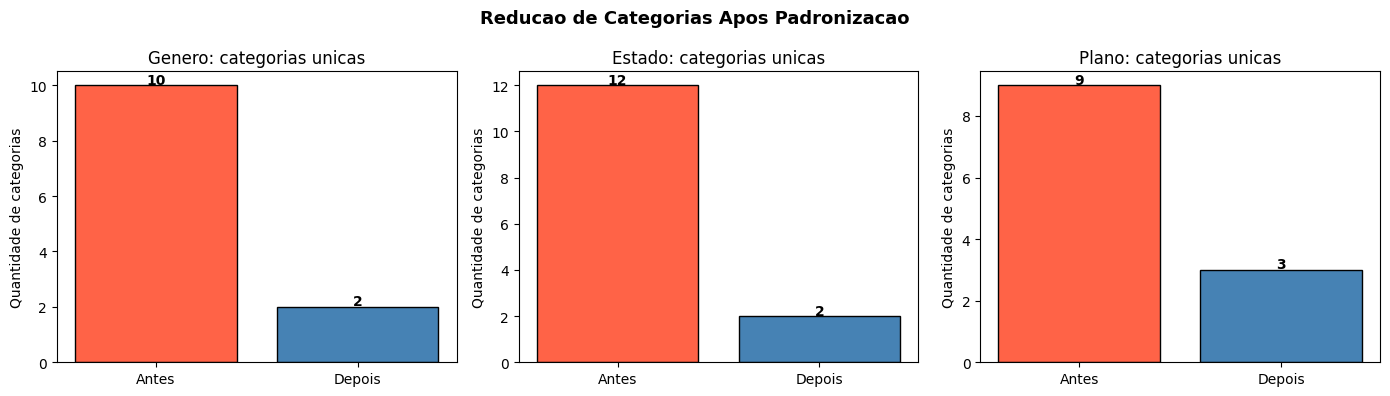

In [8]:
# Visualizacao: impacto da padronizacao no numero de categorias
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

colunas = ['genero', 'estado', 'plano']
titulos_antes = ['Genero (ANTES)', 'Estado (ANTES)', 'Plano (ANTES)']
titulos_depois = ['Genero (DEPOIS)', 'Estado (DEPOIS)', 'Plano (DEPOIS)']

for i, col in enumerate(colunas):
    antes  = df_str[col].str.strip().value_counts()
    depois = df_padronizado[col].value_counts()

    x = np.arange(2)
    axes[i].bar(['Antes', 'Depois'], [len(antes), len(depois)],
                color=['tomato', 'steelblue'], edgecolor='black')
    axes[i].set_title(f'{col.title()}: categorias unicas')
    axes[i].set_ylabel('Quantidade de categorias')
    for j, v in enumerate([len(antes), len(depois)]):
        axes[i].text(j, v + 0.05, str(v), ha='center', fontweight='bold')

plt.suptitle('Reducao de Categorias Apos Padronizacao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

<br>

---

## 3. Conversão de tipos de dados

<br>

Números armazenados como texto impedem cálculos e introduzem erros silenciosos. A conversão de tipos é uma das etapas mais críticas e frequentemente subestimadas da preparação dos dados.

<br>

**Conversões mais comuns:**
- **Datas** devem ser convertidas para o tipo `datetime` antes de qualquer operação temporal
- **Booleanos** precisam de representação consistente em todo o dataset (True/False, 1/0, Sim/Não)
- **Categóricas** devem usar o tipo `category` para reduzir uso de memória em grandes datasets
- **Numéricos** armazenados como string devem ser convertidos com tratamento de erros

<br>

**Atenção:**
- Sempre verificar se há valores inesperados que bloqueiam a conversão
- Usar `errors='coerce'` para converter o que for possível e marcar o restante como NaN

<br>

In [9]:
# Dataset com tipos errados
df_tipos_errados = pd.DataFrame({
    'id':          ['1', '2', '3', '4', '5'],
    'valor':       ['1500.50', '2300.00', 'N/A', '4100.75', '850.20'],
    'data_compra': ['2024-01-15', '20/02/2024', '2024-03-10', '2024-04-05', '05-05-2024'],
    'ativo':       ['sim', 'nao', 'SIM', 'NAO', 'sim'],
    'categoria':   ['A', 'B', 'A', 'C', 'B'],
    'qtd':         ['10', '25', '8', '30abc', '15']
})

print('Dataset com tipos errados:')
display(df_tipos_errados)
print('\nTipos atuais:')
print(df_tipos_errados.dtypes)

Dataset com tipos errados:


,id,valor,data_compra,ativo,categoria,qtd
0,1,1500.50,2024-01-15,sim,A,10
1,2,2300.00,20/02/2024,nao,B,25
2,3,N/A,2024-03-10,SIM,A,8
3,4,4100.75,2024-04-05,NAO,C,30abc
4,5,850.20,05-05-2024,sim,B,15



Tipos atuais:
id             object
valor          object
data_compra    object
ativo          object
categoria      object
qtd            object
dtype: object


In [10]:
# Conversao de tipos
df_convertido = df_tipos_errados.copy()

# ID: string para inteiro
df_convertido['id'] = df_convertido['id'].astype(int)

# Valor: string para float (N/A vira NaN)
df_convertido['valor'] = pd.to_numeric(df_convertido['valor'], errors='coerce')

# Data: multiplos formatos para datetime
# Neste caso usamos dayfirst=True para cobrir o formato DD/MM/YYYY
df_convertido['data_compra'] = pd.to_datetime(df_convertido['data_compra'],
                                               dayfirst=True, errors='coerce')

# Booleano: sim/nao para True/False
mapa_bool = {'sim': True, 'nao': False}
df_convertido['ativo'] = df_convertido['ativo'].str.lower().map(mapa_bool)

# Categorica: object para category (economiza memoria)
df_convertido['categoria'] = df_convertido['categoria'].astype('category')

# Quantidade: string para int (valores invalidos viram NaN)
df_convertido['qtd'] = pd.to_numeric(df_convertido['qtd'], errors='coerce')

print('Dataset apos conversao de tipos:')
display(df_convertido)
print('\nTipos apos conversao:')
print(df_convertido.dtypes)

Dataset apos conversao de tipos:


/tmp/ipykernel_3130/1347007091.py:12: UserWarning: Parsing dates in %Y-%m-%d format when dayfirst=True was specified. Pass `dayfirst=False` or specify a format to silence this warning.
  df_convertido['data_compra'] = pd.to_datetime(df_convertido['data_compra'],


,id,valor,data_compra,ativo,categoria,qtd
0,1,1500.5000,2024-01-15,True,A,10.0000
1,2,2300.0000,NaT,False,B,25.0000
2,3,NaN,2024-03-10,True,A,8.0000
3,4,4100.7500,2024-04-05,False,C,NaN
4,5,850.2000,NaT,True,B,15.0000



Tipos apos conversao:
id                      int64
valor                 float64
data_compra    datetime64[ns]
ativo                    bool
categoria            category
qtd                   float64
dtype: object


In [11]:
# Operacoes que so funcionam com tipos corretos
print('=== OPERACOES QUE DEPENDEM DO TIPO CORRETO ===')

# Extraindo componentes de data
df_convertido['ano']  = df_convertido['data_compra'].dt.year
df_convertido['mes']  = df_convertido['data_compra'].dt.month
df_convertido['dia_semana'] = df_convertido['data_compra'].dt.day_name()

print('Componentes de data extraidos:')
display(df_convertido[['data_compra', 'ano', 'mes', 'dia_semana']])

# Calculo so possivel com tipo numerico
print(f'\nValor medio: R$ {df_convertido["valor"].mean():.2f}')
print(f'Quantidade total: {df_convertido["qtd"].sum():.0f}')

# Filtragem por booleano
print(f'\nClientes ativos: {df_convertido["ativo"].sum()} de {len(df_convertido)}')

=== OPERACOES QUE DEPENDEM DO TIPO CORRETO ===
Componentes de data extraidos:


,data_compra,ano,mes,dia_semana
0,2024-01-15,2024.0000,1.0000,Monday
1,NaT,NaN,NaN,NaN
2,2024-03-10,2024.0000,3.0000,Sunday
3,2024-04-05,2024.0000,4.0000,Friday
4,NaT,NaN,NaN,NaN



Valor medio: R$ 2187.86
Quantidade total: 58

Clientes ativos: 3 de 5


In [12]:
# Economia de memoria com tipo category
n = 100_000
cidades = np.random.choice(['São Paulo', 'Rio de Janeiro', 'Curitiba', 'Manaus', 'Recife'], n)

serie_object   = pd.Series(cidades, dtype='object')
serie_category = pd.Series(cidades, dtype='category')

mem_object   = serie_object.memory_usage(deep=True)
mem_category = serie_category.memory_usage(deep=True)

print(f'Memoria com dtype object:   {mem_object / 1024:.1f} KB')
print(f'Memoria com dtype category: {mem_category / 1024:.1f} KB')
print(f'Reducao de memoria: {(1 - mem_category/mem_object)*100:.1f}%')
print('\nO tipo category armazena apenas os indices dos valores unicos, nao o texto completo.')

Memoria com dtype object:   5938.1 KB
Memoria com dtype category: 98.3 KB
Reducao de memoria: 98.3%

O tipo category armazena apenas os indices dos valores unicos, nao o texto completo.


<br>

---

## 4. Normalização e padronização de variáveis numéricas

<br>

Modelos sensíveis à escala, como regressão linear, redes neurais, KNN e SVM, exigem que as variáveis numéricas estejam na mesma escala. Árvores de decisão e Random Forest não precisam dessa transformação, pois são invariantes à escala.

<br>

**Normalização (Min-Max):**
- Escala os valores para o intervalo [0, 1]
- Fórmula: `x' = (x - x_min) / (x_max - x_min)`
- Sensível a outliers, pois depende dos valores extremos
- Indicada para redes neurais e KNN

<br>

**Padronização (Z-score):**
- Resulta em média 0 e desvio padrão 1
- Fórmula: `x' = (x - média) / desvio_padrão`
- Mais robusta a outliers do que a normalização
- Indicada para regressão linear, regressão logística e SVM

<br>

**Regra importante:** o scaler deve ser ajustado (fit) apenas nos dados de treino e aplicado (transform) tanto no treino quanto no teste. Ajustar no dataset completo é data leakage.

<br>

In [13]:
# Dataset de exemplo para escalonamento
np.random.seed(42)
n = 300

df_escala = pd.DataFrame({
    'idade':       np.random.randint(18, 70, n),
    'renda':       np.random.lognormal(8.5, 0.6, n).round(2),
    'num_filhos':  np.random.poisson(1.2, n),
    'score_credito': np.random.normal(650, 80, n).clip(300, 1000).round(0)
})

print('Estatisticas originais:')
display(df_escala.describe().round(2))
print('\nAs variaveis estao em escalas muito diferentes. Renda vai ate milhares, num_filhos ate 5.')

Estatisticas originais:


,idade,renda,num_filhos,score_credito
count,300.0000,300.0000,300.0000,300.0000
mean,43.3200,5845.3500,1.2200,659.4700
std,15.3300,3933.7500,1.1200,85.5000
min,18.0000,652.9800,0.0000,441.0000
25%,30.0000,3144.3300,0.0000,601.7500
50%,43.5000,4890.8000,1.0000,659.0000
75%,56.0000,7779.6500,2.0000,721.2500
max,69.0000,33263.6300,5.0000,898.0000



As variaveis estao em escalas muito diferentes. Renda vai ate milhares, num_filhos ate 5.


In [14]:
# Aplicando Normalizacao (Min-Max) e Padronizacao (Z-score)
from sklearn.model_selection import train_test_split

X_train, X_test = train_test_split(df_escala, test_size=0.2, random_state=42)

# Normalizacao Min-Max
minmax = MinMaxScaler()
minmax.fit(X_train)  # fit SOMENTE no treino
X_train_mm = pd.DataFrame(minmax.transform(X_train), columns=df_escala.columns)
X_test_mm  = pd.DataFrame(minmax.transform(X_test),  columns=df_escala.columns)

# Padronizacao Z-score
zscore = StandardScaler()
zscore.fit(X_train)  # fit SOMENTE no treino
X_train_zs = pd.DataFrame(zscore.transform(X_train), columns=df_escala.columns)
X_test_zs  = pd.DataFrame(zscore.transform(X_test),  columns=df_escala.columns)

print('Estatisticas apos Normalizacao (Min-Max):')
display(X_train_mm.describe().round(4))

print('\nEstatisticas apos Padronizacao (Z-score):')
display(X_train_zs.describe().round(4))

Estatisticas apos Normalizacao (Min-Max):


,idade,renda,num_filhos,score_credito
count,240.0000,240.0000,240.0000,240.0000
mean,0.4946,0.1591,0.2442,0.5257
std,0.2983,0.1231,0.2200,0.2060
min,0.0000,0.0000,0.0000,0.0000
25%,0.2500,0.0733,0.0000,0.3753
50%,0.5000,0.1260,0.2000,0.5182
75%,0.7451,0.2248,0.4000,0.6877
max,1.0000,1.0000,1.0000,1.0000



Estatisticas apos Padronizacao (Z-score):


,idade,renda,num_filhos,score_credito
count,240.0000,240.0000,240.0000,240.0000
mean,-0.0000,0.0000,-0.0000,-0.0000
std,1.0021,1.0021,1.0021,1.0021
min,-1.6617,-1.2959,-1.1120,-2.5567
25%,-0.8218,-0.6993,-1.1120,-0.7315
50%,0.0181,-0.2695,-0.2011,-0.0367
75%,0.8415,0.5351,0.7097,0.7876
max,1.6979,6.8477,3.4422,2.3067


In [ ]:
# Visualizacao: distribuicoes antes e depois do escalonamento
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
colunas_plot = ['renda', 'idade', 'score_credito']

for i, col in enumerate(colunas_plot):
    # Original
    axes[i, 0].hist(X_train[col], bins=30, color='gray', edgecolor='black', alpha=0.8)
    axes[i, 0].set_title(f'{col} (Original)')

    # Min-Max
    axes[i, 1].hist(X_train_mm[col], bins=30, color='steelblue', edgecolor='black', alpha=0.8)
    axes[i, 1].set_title(f'{col} (Min-Max)')

    # Z-score
    axes[i, 2].hist(X_train_zs[col], bins=30, color='seagreen', edgecolor='black', alpha=0.8)
    axes[i, 2].set_title(f'{col} (Z-score)')

plt.suptitle('Distribuicoes: Original vs Normalizacao vs Padronizacao', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
print('A forma da distribuicao nao muda. Apenas a escala do eixo x muda.')

In [ ]:
# Impacto de outliers na normalizacao
serie_normal  = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 100])
serie_outlier = np.array([10, 20, 30, 40, 50, 60, 70, 80, 90, 10000])  # outlier extremo

def normalizar(arr):
    return (arr - arr.min()) / (arr.max() - arr.min())

def padronizar(arr):
    return (arr - arr.mean()) / arr.std()

print('Valores normalizados (Min-Max) SEM outlier:')
print(normalizar(serie_normal).round(3))

print('\nValores normalizados (Min-Max) COM outlier (todos comprimidos entre 0 e 0.01!):')
print(normalizar(serie_outlier).round(3))

print('\nValores padronizados (Z-score) SEM outlier:')
print(padronizar(serie_normal).round(3))

print('\nValores padronizados (Z-score) COM outlier (menos afetado):')
print(padronizar(serie_outlier).round(3))

print('\nConclusao: com outliers presentes, Z-score e mais robusto que Min-Max.')

<br>

---

## 5. Pipelines de pré-processamento

<br>

Um pipeline encadeia transformações de forma reprodutível e sem vazamento de dados. É a forma correta de aplicar preparação de dados em projetos reais.

<br>

**Vantagens principais:**
- O ajuste (fit) é feito apenas nos dados de treino e a transformação é aplicada ao teste automaticamente
- Facilita validação cruzada, pois cada fold é tratado de forma independente
- Simplifica o deploy do modelo: um único objeto encapsula toda a preparação e o modelo
- Código mais limpo, auditável e reutilizável

<br>

**Estrutura típica de um pipeline:**
- Imputação de valores faltantes
- Encoding de variáveis categóricas
- Escalonamento de variáveis numéricas
- Modelo

<br>

In [ ]:
# Dataset realista com numericas, categoricas e valores faltantes
np.random.seed(42)
n = 500

df_pipeline = pd.DataFrame({
    'idade':       np.random.randint(18, 65, n).astype(float),
    'renda':       np.random.lognormal(8.5, 0.6, n).round(2),
    'score':       np.random.normal(650, 80, n).clip(300, 1000).round(0),
    'cidade':      np.random.choice(['São Paulo', 'Rio de Janeiro', 'Curitiba', None], n, p=[0.4, 0.3, 0.2, 0.1]),
    'escolaridade':np.random.choice(['Fundamental', 'Medio', 'Superior', None], n, p=[0.2, 0.35, 0.35, 0.1]),
    'inadimplente':np.random.choice([0, 1], n, p=[0.8, 0.2])
})

# Introduzir faltantes nas numericas
idx_faltante = np.random.choice(n, size=40, replace=False)
df_pipeline.loc[idx_faltante[:20], 'idade'] = np.nan
df_pipeline.loc[idx_faltante[20:], 'renda'] = np.nan

print('Dataset para o pipeline:')
print(df_pipeline.head(8).to_string())
print(f'\nShape: {df_pipeline.shape}')
print('\nValores nulos por coluna:')
print(df_pipeline.isnull().sum())

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

# Separar features e target
X = df_pipeline.drop(columns=['inadimplente'])
y = df_pipeline['inadimplente']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Definir colunas por tipo
cols_numericas   = ['idade', 'renda', 'score']
cols_nominais    = ['cidade']
cols_ordinais    = ['escolaridade']
ordem_escolaridade = [['Fundamental', 'Medio', 'Superior']]

print(f'Tamanho treino: {X_train.shape}')
print(f'Tamanho teste:  {X_test.shape}')

In [ ]:
# Construindo o pipeline com ColumnTransformer

# Sub-pipeline para variaveis numericas
pipe_numericas = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler',  StandardScaler())
])

# Sub-pipeline para variaveis nominais
pipe_nominais = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# Sub-pipeline para variaveis ordinais
pipe_ordinais = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=ordem_escolaridade,
                               handle_unknown='use_encoded_value',
                               unknown_value=-1))
])

# Combinando tudo com ColumnTransformer
preprocessador = ColumnTransformer([
    ('numericas', pipe_numericas, cols_numericas),
    ('nominais',  pipe_nominais,  cols_nominais),
    ('ordinais',  pipe_ordinais,  cols_ordinais)
])

# Pipeline final: preprocessamento + modelo
pipeline_final = Pipeline([
    ('preprocessamento', preprocessador),
    ('modelo',           LogisticRegression(max_iter=1000, random_state=42))
])

print('Pipeline construido com sucesso.')
print(pipeline_final)

In [ ]:
# Treinando e avaliando
pipeline_final.fit(X_train, y_train)

y_pred = pipeline_final.predict(X_test)

print('=== RESULTADO DO MODELO ===')
print(classification_report(y_test, y_pred, target_names=['Adimplente', 'Inadimplente']))
print('\nTodo o preprocessamento foi aplicado corretamente dentro do pipeline.')
print('O fit do scaler e dos encoders usou apenas os dados de treino.')

In [ ]:
# Demonstrando o risco de fazer preprocessamento fora do pipeline
print('=== DATA LEAKAGE NO PREPROCESSAMENTO ===')
print()
print('ERRADO: ajustar o scaler em todo o dataset antes de separar treino/teste')
print()
print('  scaler = StandardScaler()')
print('  X_scaled = scaler.fit_transform(X)          <- fit usa informacao do teste')
print('  X_train, X_test = train_test_split(X_scaled)')
print()
print('  O scaler aprendeu a media e o desvio do conjunto completo,')
print('  incluindo os dados de teste. O modelo viu informacao que nao deveria.')
print()
print('CORRETO: usar Pipeline ou fazer fit/transform separados por split')
print()
print('  scaler = StandardScaler()')
print('  scaler.fit(X_train)                         <- fit apenas no treino')
print('  X_train_scaled = scaler.transform(X_train)')
print('  X_test_scaled  = scaler.transform(X_test)   <- apenas transform no teste')

<br>

---

## Resumo

<br>

**O que vimos neste notebook:**

- Duplicatas podem ser exatas, parciais ou fuzzy e cada tipo exige uma estratégia diferente de tratamento
- Padronização de strings reduz o número de categorias espúrias e melhora a qualidade do dataset
- Conversão de tipos é obrigatória antes de qualquer operação numérica, temporal ou lógica
- Normalização (Min-Max) e Padronização (Z-score) têm casos de uso distintos conforme o algoritmo e a presença de outliers
- Pipelines garantem que o preprocessamento seja aplicado sem leakage, de forma reprodutível e pronta para deploy

<br>

**Próximo notebook:** Dados Faltantes.